# Credit Risk & Loan Default Prediction
## Phase 1 — Data Understanding & Cleaning

**The business question.** A bank has to decide, borrower by borrower, whether to lend. In my year as a Consumer Account Manager at Postal Savings Bank of China I made that judgment by hand in 320+ pre-loan credit investigations. This project asks: *can a model learn to spot which borrowers are likely to fall seriously behind on payments, and what does it get right or wrong?*

**What this notebook does (Phase 1 only).** Before any modeling we have to understand the raw data and fix its problems. Models trained on messy data give confident-looking but wrong answers ("garbage in, garbage out"). By the end of this notebook we will have:

1. Looked at what is in the data (size, columns, missing values).
2. Found the suspicious values (impossible ages, strange codes, absurd ratios).
3. Decided how to handle each one, and written down *why*.
4. Saved a cleaned dataset for the next phase.

**Dataset.** *Give Me Some Credit* (Kaggle competition). Each row is one borrower. The target column `SeriousDlqin2yrs` is `1` if the person became **seriously delinquent** (90+ days past due on a payment) within two years, and `0` otherwise. Delinquency is the standard stand-in for "default" in this dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")

RAW_PATH = "../data/cs-training.csv"
CLEAN_PATH = "../data/cs-training-clean.csv"
TARGET = "SeriousDlqin2yrs"

## 1. Load the data and take a first look

In [2]:
raw = pd.read_csv(RAW_PATH, index_col=0)
print(f"{raw.shape[0]:,} borrowers, {raw.shape[1]} columns")
raw.head()

150,000 borrowers, 11 columns


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


**Column meanings (from the Kaggle data dictionary):**

| Column | Plain-English meaning |
|---|---|
| `SeriousDlqin2yrs` | **Target.** 1 = went 90+ days past due within 2 years |
| `RevolvingUtilizationOfUnsecuredLines` | How much of their credit-card / credit-line limit they are using (0.5 = using half) |
| `age` | Age in years |
| `NumberOfTime30-59DaysPastDueNotWorse` | Times 30–59 days late in the last 2 years |
| `NumberOfTime60-89DaysPastDueNotWorse` | Times 60–89 days late in the last 2 years |
| `NumberOfTimes90DaysLate` | Times 90+ days late |
| `DebtRatio` | Monthly debt payments and living costs divided by monthly gross income |
| `MonthlyIncome` | Monthly income |
| `NumberOfOpenCreditLinesAndLoans` | Open loans and credit lines (credit cards, car loans, mortgages) |
| `NumberRealEstateLoansOrLines` | Mortgages and home-equity lines |
| `NumberOfDependents` | Family members supported (excluding the borrower) |

A quick point of comparison with my bank experience: these are close to the things I looked at manually: income, existing debt, repayment history. The big difference is that the model sees only these numbers, not the person or their story.

In [3]:
raw.dtypes

SeriousDlqin2yrs                          int64
RevolvingUtilizationOfUnsecuredLines    float64
age                                       int64
NumberOfTime30-59DaysPastDueNotWorse      int64
DebtRatio                               float64
MonthlyIncome                           float64
NumberOfOpenCreditLinesAndLoans           int64
NumberOfTimes90DaysLate                   int64
NumberRealEstateLoansOrLines              int64
NumberOfTime60-89DaysPastDueNotWorse      int64
NumberOfDependents                      float64
dtype: object

## 2. Missing values

Empty cells are a problem because most models cannot use a row with a hole in it. First, how many are there?

In [4]:
missing = raw.isna().sum()
missing_pct = (raw.isna().mean() * 100).round(2)
missing_table = pd.DataFrame({"missing_rows": missing, "missing_%": missing_pct})
missing_table[missing_table.missing_rows > 0]

,missing_rows,missing_%
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62


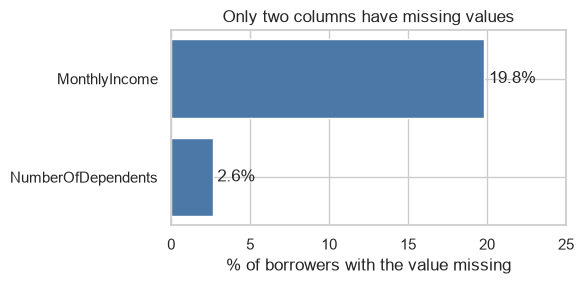

In [5]:
fig, ax = plt.subplots(figsize=(6, 3))
m = missing_pct[missing_pct > 0].sort_values()
ax.barh(m.index, m.values, color="#4C78A8")
ax.set_xlabel("% of borrowers with the value missing")
ax.set_title("Only two columns have missing values")
for y, v in enumerate(m.values):
    ax.text(v + 0.3, y, f"{v:.1f}%", va="center")
ax.set_xlim(0, 25)
plt.tight_layout()
plt.savefig("../reports/01_missing_values.png", dpi=150)
plt.show()

**What this shows.** About **20% of borrowers have no `MonthlyIncome`** and about **2.6% have no `NumberOfDependents`**. Everything else is complete.

**Is the missingness itself informative?** In real lending, "income not provided" can mean something. Let's check whether these borrowers default at a different rate.

In [6]:
print("Overall default rate: {:.2%}".format(raw[TARGET].mean()))
print()
print("Default rate by whether income is missing:")
print(raw.groupby(raw.MonthlyIncome.isna())[TARGET].mean().map("{:.2%}".format).rename({False: "income present", True: "income missing"}))
print()
print("Default rate by whether dependents is missing:")
print(raw.groupby(raw.NumberOfDependents.isna())[TARGET].mean().map("{:.2%}".format).rename({False: "dependents present", True: "dependents missing"}))

Overall default rate: 6.68%

Default rate by whether income is missing:
MonthlyIncome
income present    6.95%
income missing    5.61%
Name: SeriousDlqin2yrs, dtype: str

Default rate by whether dependents is missing:
NumberOfDependents
dependents present    6.74%
dependents missing    4.56%
Name: SeriousDlqin2yrs, dtype: str


**Takeaway.** Borrowers with missing income default a little *less* often (5.6% vs. 7.0%), and those with missing dependents even less (4.6%). The gap is small but real, so we will keep a "was missing" flag column alongside whatever value we fill in. That way the model can still use the fact that the information was absent.

Also worth noting: only about **6.7% of borrowers default**. That is a strongly **imbalanced** target. A lazy model that predicts "nobody defaults" would be 93% accurate and completely useless. This is why we will not use plain accuracy as our metric later.

## 3. Summary statistics: spotting the suspicious values

`describe()` shows the smallest value, largest value, and typical (median) value of each column. We look for numbers that are impossible or wildly far from typical.

In [7]:
raw.describe(percentiles=[0.01, 0.5, 0.99]).T.round(2)

,count,mean,std,min,1%,50%,99%,max
SeriousDlqin2yrs,150000.0,0.07,0.25,0.0,0.0,0.00,1.00,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.05,249.76,0.0,0.0,0.15,1.09,50708.0
age,150000.0,52.30,14.77,0.0,24.0,52.00,87.00,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.42,4.19,0.0,0.0,0.00,4.00,98.0
DebtRatio,150000.0,353.01,2037.82,0.0,0.0,0.37,4979.04,329664.0
MonthlyIncome,120269.0,6670.22,14384.67,0.0,0.0,5400.00,25000.00,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.45,5.15,0.0,0.0,8.00,24.00,58.0
NumberOfTimes90DaysLate,150000.0,0.27,4.17,0.0,0.0,0.00,3.00,98.0
NumberRealEstateLoansOrLines,150000.0,1.02,1.13,0.0,0.0,1.00,4.00,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.24,4.16,0.0,0.0,0.00,2.00,98.0


**Things that jump out** (comparing the `50%` typical value with the `max`):

- `age` has a minimum of **0**. A borrower cannot be 0 years old.
- `RevolvingUtilizationOfUnsecuredLines` has a median of 0.15 but a max of **50,708**. Utilization is a percentage of a credit limit, so 50,708× the limit is not believable.
- `DebtRatio` has a median of 0.37 but a max of **329,664**.
- The three "times past due" columns have a max of **98**: nobody is 98 times late in two years.
- `MonthlyIncome` has a max of **$3 million** per month, and 1,634 borrowers report exactly **$0**.

We take these one at a time.

## 4. Cleaning, issue by issue

We work on a copy so the raw data stays untouched, and keep a log of every change we make.

In [8]:
df = raw.copy()
cleaning_log = []   # (issue, rows affected, what we did)

### Issue A: an age of 0

A single borrower has `age = 0`. This is clearly a data-entry error, and we cannot know the true age.

In [9]:
print("Rows with age < 18:", (df.age < 18).sum())
print("Youngest valid ages:", sorted(df.age[df.age > 0].unique())[:5])
print("Oldest age:", df.age.max())

Rows with age < 18: 1
Youngest valid ages: [np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25)]
Oldest age: 109


**Decision:** drop that one row. With 150,000 borrowers, losing one costs nothing, and guessing an age would be inventing data. (The youngest real borrower is 21 and the oldest is 109, both believable.)

In [10]:
n_before = len(df)
df = df[df.age >= 18]
cleaning_log.append(("Age of 0", n_before - len(df), "Dropped the row"))
print(f"Dropped {n_before - len(df)} row. {len(df):,} remain.")

Dropped 1 row. 149,999 remain.


### Issue B: the mystery values 96 and 98 in the "times past due" columns

Look at the highest values in each of the three past-due columns:

In [11]:
past_due_cols = ["NumberOfTime30-59DaysPastDueNotWorse",
                 "NumberOfTime60-89DaysPastDueNotWorse",
                 "NumberOfTimes90DaysLate"]
for c in past_due_cols:
    print(c)
    print("  ", df[c].value_counts().sort_index().tail(6).to_dict())

NumberOfTime30-59DaysPastDueNotWorse
   {10: 4, 11: 1, 12: 2, 13: 1, 96: 5, 98: 264}
NumberOfTime60-89DaysPastDueNotWorse
   {7: 9, 8: 2, 9: 1, 11: 1, 96: 5, 98: 264}
NumberOfTimes90DaysLate
   {13: 4, 14: 2, 15: 2, 17: 1, 96: 5, 98: 264}


Notice the jump: counts go 11, 12, 13... and then suddenly **96** and **98**, with 264 borrowers at exactly 98. Real counts don't behave like this. These look like **special codes** the data collector used (for example "unknown" or "not applicable") rather than true counts.

Let's check that these are the same borrowers across all three columns, and whether they behave differently from everyone else.

In [12]:
code_mask = (df[past_due_cols] >= 96).any(axis=1)
all_three = (df[past_due_cols] >= 96).all(axis=1)
print(f"Borrowers with a 96/98 code in any of the 3 columns: {code_mask.sum()}")
print(f"...in all three columns at once:                     {all_three.sum()}")
print()
print("Default rate, code borrowers  : {:.1%}".format(df.loc[code_mask, TARGET].mean()))
print("Default rate, everyone else   : {:.1%}".format(df.loc[~code_mask, TARGET].mean()))

Borrowers with a 96/98 code in any of the 3 columns: 269
...in all three columns at once:                     269

Default rate, code borrowers  : 54.6%
Default rate, everyone else   : 6.6%


**What this shows.** The 96/98 values appear in the *same* ~269 borrowers across all three columns, and those borrowers default at **~55%, more than 8 times the average**. So they are not random errors: something about these accounts makes them very risky. Deleting them would throw away real signal, and treating 98 as "98 late payments" would distort the math.

**Decision (a judgment call):** keep these rows, but
1. add a flag column `past_due_code_flag = 1` for them (so the model can learn "this special category is high risk"), and
2. replace the 96/98 with the **largest genuine count in that same column** (13, 11 and 17 respectively), so the numbers are still on a believable scale.

The alternative would be to treat them as missing and fill in the median (0 late payments). That would label the *riskiest* group as *spotless*. We rejected this for that reason.

In [13]:
df["past_due_code_flag"] = code_mask.astype(int)
for c in past_due_cols:
    legit_max = df.loc[df[c] < 96, c].max()
    df.loc[df[c] >= 96, c] = legit_max
cleaning_log.append(("96/98 codes in past-due columns", int(code_mask.sum()),
                     "Added past_due_code_flag; set to the column's largest genuine value"))
print(df[past_due_cols].max())

NumberOfTime30-59DaysPastDueNotWorse    13
NumberOfTime60-89DaysPastDueNotWorse    11
NumberOfTimes90DaysLate                 17
dtype: int64


### Issue C: credit utilization far above 100%

Utilization is *balance ÷ credit limit*. Above 1.0 means the borrower is over their limit, which does happen, so values slightly above 1 are believable. But a value like 50,000 is not.

In [14]:
u = "RevolvingUtilizationOfUnsecuredLines"
for cut in [1, 2, 5, 10]:
    print(f"utilization > {cut:>2}: {(df[u] > cut).sum():>5,} borrowers")
print()
print("Default rate by utilization level:")
bins = pd.cut(df[u], [-0.001, 0.25, 0.5, 0.75, 1, 2, np.inf], labels=["0-25%", "25-50%", "50-75%", "75-100%", "100-200%", ">200%"])
print(df.groupby(bins, observed=True)[TARGET].agg(["mean", "size"]).rename(columns={"mean": "default_rate", "size": "borrowers"}).round(3))

utilization >  1: 3,321 borrowers
utilization >  2:   371 borrowers
utilization >  5:   254 borrowers
utilization > 10:   241 borrowers

Default rate by utilization level:
                                      default_rate  borrowers
RevolvingUtilizationOfUnsecuredLines                         
0-25%                                        0.021      87657
25-50%                                       0.053      21055
50-75%                                       0.101      13764
75-100%                                      0.182      24202
100-200%                                     0.401       2950
>200%                                        0.146        371


**What this shows.** Risk climbs steadily with utilization: about 2% default for borrowers using under 25% of their limit, 18% at 75-100%, and **40% for those over their limit (100-200%)**. But past 200% the default rate *falls* to about 15% (only 371 borrowers). If these people were genuinely maxed out two or three times over, you'd expect risk to keep rising, not drop by more than half. That pattern suggests many of these values are recording errors (for example a dollar balance entered instead of a ratio), though we cannot prove it from the data alone.

**Decision:** cap utilization at **2.0** (200%). Values between 1 and 2 are treated as real over-limit borrowers; anything above is treated as a recording error and pulled down to the cap. Capping (rather than deleting) keeps the borrower in the data. Only 371 rows are touched, so the effect of this choice is small.

In [15]:
n_capped = int((df[u] > 2).sum())
df[u] = df[u].clip(upper=2)
cleaning_log.append(("Utilization above 2.0", n_capped, "Capped at 2.0"))
print(f"Capped {n_capped} values. New max: {df[u].max()}")

Capped 371 values. New max: 2.0


### Issue D: the absurd DebtRatio, and its link to missing income

`DebtRatio` = monthly debts ÷ monthly income. A typical borrower is 0.37 (37% of income goes to debt). But 23% of borrowers have a ratio above 1 (debts bigger than income) and 16% have a ratio above 100. Something is off. Recall that 20% of borrowers are missing income. Are they the same people?

In [16]:
dr = "DebtRatio"
inc_missing = df.MonthlyIncome.isna()
print("Borrowers with DebtRatio > 1:", f"{(df[dr] > 1).sum():,}")
print("  ...of which income is missing:", f"{((df[dr] > 1) & inc_missing).sum():,}")
print()
print("DebtRatio, income PRESENT:")
print(df.loc[~inc_missing, dr].describe(percentiles=[.5, .9, .99]).round(2))
print()
print("DebtRatio, income MISSING:")
print(df.loc[inc_missing, dr].describe(percentiles=[.5, .9, .99]).round(2))

Borrowers with DebtRatio > 1: 35,137
  ...of which income is missing: 27,904

DebtRatio, income PRESENT:
count    120268.00
mean         26.60
std         424.45
min           0.00
50%           0.30
90%           0.76
99%         661.83
max       61106.50
Name: DebtRatio, dtype: float64

DebtRatio, income MISSING:
count     29731.00
mean       1673.40
std        4248.37
min           0.00
50%        1159.00
90%        3785.00
99%        8084.50
max      329664.00
Name: DebtRatio, dtype: float64


**What this shows.** Of the 35,000 borrowers with a "ratio" above 1, nearly 28,000 (about 80%) are ones with **missing income**. For those borrowers the typical DebtRatio is around **1,159**, while for borrowers with income it is around **0.3**.

The likely explanation: the ratio is *debt ÷ income*, and when income is unknown the column appears to hold the **raw dollar amount of debt** instead of a ratio. That is a guess from the pattern; the dataset documentation doesn't confirm it. Either way, for those rows `DebtRatio` is **not comparable** with the rest and would badly distort a model (especially logistic regression).

That explains 28,000 of the 35,000. What about the other ~7,200 borrowers who *do* have income but a ratio above 1? Let's see how the default rate and income change as the ratio grows (income-present rows only):

In [17]:
present = df[df.MonthlyIncome.notna()]
bands = pd.cut(present[dr], [-0.001, 0.5, 1, 2, 5, 50, np.inf], labels=["0-0.5", "0.5-1", "1-2", "2-5", "5-50", ">50"])
present.groupby(bands, observed=True).agg(borrowers=(dr, "size"), default_rate=(TARGET, "mean"), median_income=("MonthlyIncome", "median")).round(3)

,borrowers,default_rate,median_income
DebtRatio,,,
0-0.5,92085,0.060,5883.0
0.5-1,20950,0.099,4750.0
1-2,3932,0.137,2838.5
2-5,949,0.101,1250.0
5-50,556,0.045,100.0
>50,1796,0.041,0.0


**What this shows.** Up to a ratio of about 2, everything behaves sensibly: risk rises from 6% to 14% as debts approach and then exceed income (households really can owe more than they earn). But above 5 the picture changes: the median income of these borrowers collapses to **$100 or $0**, and the default rate drops to about 4%. Dividing a dollar debt by an income of $0 or $1 produces a huge "ratio" that is really just the dollar debt again. So ratios above ~5 look like the same problem as the missing-income rows.

**Decision:** treat `DebtRatio` as **unreliable** if income is missing **or** the ratio is above 5. For those rows, replace it with the median ratio of the trustworthy rows, and add a flag column so the model knows. The cutoff of 5 is a judgment call.

In [18]:
DR_MAX_PLAUSIBLE = 5
inc_missing = df.MonthlyIncome.isna()
unreliable = inc_missing | (df[dr] > DR_MAX_PLAUSIBLE)
dr_median_trusted = df.loc[~unreliable, dr].median()

df["debt_ratio_unreliable_flag"] = unreliable.astype(int)
n_missing_inc = int(inc_missing.sum())
n_high = int((~inc_missing & (df[dr] > DR_MAX_PLAUSIBLE)).sum())
df.loc[unreliable, dr] = dr_median_trusted

cleaning_log.append(("DebtRatio unreliable: income missing", n_missing_inc,
                     f"Replaced with trusted median ({dr_median_trusted:.2f}); flagged"))
cleaning_log.append((f"DebtRatio unreliable: ratio above {DR_MAX_PLAUSIBLE} (income present)", n_high,
                     f"Replaced with trusted median ({dr_median_trusted:.2f}); flagged"))
print(f"Trusted median ratio: {dr_median_trusted:.3f}")
print(f"Replaced {n_missing_inc:,} (income missing) + {n_high:,} (ratio > {DR_MAX_PLAUSIBLE}) values. New max DebtRatio: {df[dr].max():.2f}")

Trusted median ratio: 0.290
Replaced 29,731 (income missing) + 2,352 (ratio > 5) values. New max DebtRatio: 5.00


### Issue E: extreme and zero incomes

Now the income column itself. It has two oddities: a handful of huge values (max $3 million/month) and 1,634 borrowers reporting exactly $0.

In [19]:
inc = df.MonthlyIncome.dropna()
print("Income percentiles:")
print(inc.quantile([.01, .25, .5, .75, .95, .99, .999, 1]).round(0).to_string())
print()
print(f"Borrowers reporting $0 income: {(inc == 0).sum():,}")
print("Default rate, $0 income: {:.1%}   (overall {:.1%})".format(df.loc[df.MonthlyIncome == 0, TARGET].mean(), df[TARGET].mean()))

Income percentiles:
0.010          0.0
0.250       3400.0
0.500       5400.0
0.750       8249.0
0.950      14588.0
0.990      25000.0
0.999      78396.0
1.000    3008750.0

Borrowers reporting $0 income: 1,634
Default rate, $0 income: 4.0%   (overall 6.7%)


**What this shows.** 99.9% of borrowers earn under about $78,000/month; the top few are far beyond that. The $0-income borrowers default *less* often than average (4.0% vs. 6.7%), which is the opposite of what "no income" would suggest in real life. So $0 doesn't behave like a normal income figure. It could mean retired, income not recorded, or something else; we can't tell.

**Decisions:**
- **Keep $0 as it is.** We can't tell what it means, so we don't invent a value.
- **Cap the very top at the 99.9th percentile.** Ultra-high incomes are rare and would stretch scales for no benefit.

In [20]:
inc_cap = df.MonthlyIncome.quantile(0.999)
n_inc_cap = int((df.MonthlyIncome > inc_cap).sum())
df["MonthlyIncome"] = df.MonthlyIncome.clip(upper=inc_cap)
cleaning_log.append(("Extreme MonthlyIncome", n_inc_cap, f"Capped at 99.9th percentile ({inc_cap:,.0f})"))
print(f"Capped {n_inc_cap} incomes at {inc_cap:,.0f}")

Capped 121 incomes at 78,396


### Issue F: duplicate rows

In [21]:
dups = raw.duplicated().sum()
print(f"Fully identical rows in the raw data: {dups}")

Fully identical rows in the raw data: 609


There are a few hundred fully identical rows out of 150,000 (0.4%). The file has no borrower ID, so we can't tell an accidental duplicate from two different borrowers who happen to look the same. **Decision:** leave them; at 0.4% of rows they cannot change the results much. Removing real borrowers would be a bigger mistake than keeping a tiny number of repeats.

## 5. Filling in the missing values

Now the missing values from Section 2.

### Missing `MonthlyIncome` (20%)
Deleting 20% of borrowers would waste a lot of data, and those borrowers default at a different rate than the rest. Instead we **fill in a typical value** and keep a flag recording that it was missing.

**Which typical value?** Income varies a lot with age (people in their 40s and 50s tend to earn more than people in their 20s), so a single overall number would be a crude guess. We use the **median income within each age band**. We choose the *median* rather than the *mean* because a few very high earners pull the mean up; the median better represents a typical person.

In [22]:
df["income_missing_flag"] = df.MonthlyIncome.isna().astype(int)

age_bins = [17, 29, 39, 49, 59, 69, 120]
age_labels = ["18-29", "30-39", "40-49", "50-59", "60-69", "70+"]
df["age_band"] = pd.cut(df.age, bins=age_bins, labels=age_labels)

income_by_age = df.groupby("age_band", observed=True).MonthlyIncome.median()
print("Median monthly income by age band (non-missing rows):")
print(income_by_age.round(0).to_string())

n_inc_fill = int(df.MonthlyIncome.isna().sum())
df["MonthlyIncome"] = df.MonthlyIncome.fillna(df.age_band.map(income_by_age).astype(float))
cleaning_log.append(("Missing MonthlyIncome", n_inc_fill, "Filled with median by age band; income_missing_flag added"))
print(f"\nFilled {n_inc_fill:,} missing incomes. Remaining missing: {df.MonthlyIncome.isna().sum()}")

Median monthly income by age band (non-missing rows):
age_band
18-29    2557.0
30-39    4666.0
40-49    6000.0
50-59    6333.0
60-69    5918.0
70+      4550.0

Filled 29,731 missing incomes. Remaining missing: 0


### Missing `NumberOfDependents` (2.6%)
Most borrowers have no dependents (median and most common value = 0), so filling with 0 is the natural choice and hardly changes anything. As with income, we keep a flag.

In [23]:
df["dependents_missing_flag"] = df.NumberOfDependents.isna().astype(int)
n_dep_fill = int(df.NumberOfDependents.isna().sum())
print("Most common value:", df.NumberOfDependents.mode()[0], " median:", df.NumberOfDependents.median())
df["NumberOfDependents"] = df.NumberOfDependents.fillna(0)
cleaning_log.append(("Missing NumberOfDependents", n_dep_fill, "Filled with 0 (median/mode); dependents_missing_flag added"))

Most common value: 0.0  median: 0.0


## 6. Before vs. after

In [24]:
assert df.isna().sum().sum() == 0, "There are still missing values"
print(f"Rows: {len(raw):,} -> {len(df):,}   Missing cells: {int(raw.isna().sum().sum()):,} -> {int(df.isna().sum().sum())}")
print(f"Default rate: {raw[TARGET].mean():.2%} -> {df[TARGET].mean():.2%}")
print()
cols = ["RevolvingUtilizationOfUnsecuredLines", "age", "DebtRatio", "MonthlyIncome"]
comp = pd.concat({"before (max)": raw[cols].max(), "after (max)": df[cols].max()}, axis=1)
comp.round(2)

Rows: 150,000 -> 149,999   Missing cells: 33,655 -> 0
Default rate: 6.68% -> 6.68%



,before (max),after (max)
RevolvingUtilizationOfUnsecuredLines,50708.0,2.00
age,109.0,109.00
DebtRatio,329664.0,5.00
MonthlyIncome,3008750.0,78396.14


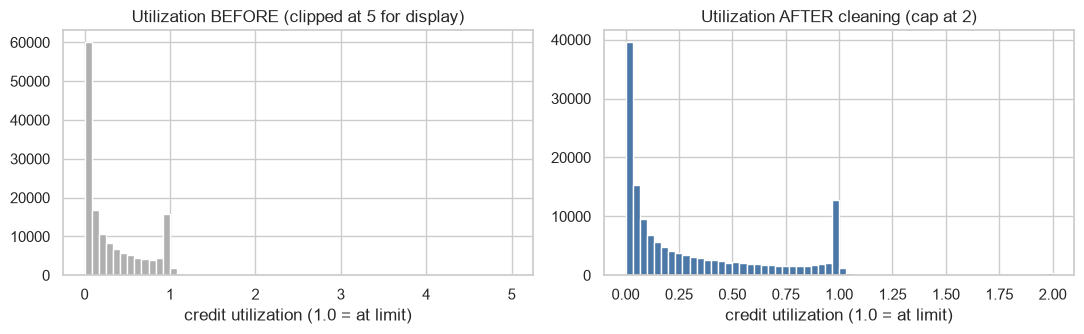

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(raw[u].clip(upper=5), bins=60, color="#B0B0B0")
axes[0].set_title("Utilization BEFORE (clipped at 5 for display)")
axes[1].hist(df[u], bins=60, color="#4C78A8")
axes[1].set_title("Utilization AFTER cleaning (cap at 2)")
for a in axes:
    a.set_xlabel("credit utilization (1.0 = at limit)")
plt.tight_layout()
plt.savefig("../reports/01_utilization_before_after.png", dpi=150)
plt.show()

### Full cleaning log
Every change we made, in one table. It is the complete record of how each data problem was handled.

In [26]:
log = pd.DataFrame(cleaning_log, columns=["Issue", "Rows affected", "Action"])
log

,Issue,Rows affected,Action
0,Age of 0,1,Dropped the row
1,96/98 codes in past-due columns,269,Added past_due_code_flag; set to the column's ...
2,Utilization above 2.0,371,Capped at 2.0
3,DebtRatio unreliable: income missing,29731,Replaced with trusted median (0.29); flagged
4,DebtRatio unreliable: ratio above 5 (income pr...,2352,Replaced with trusted median (0.29); flagged
5,Extreme MonthlyIncome,121,"Capped at 99.9th percentile (78,396)"
6,Missing MonthlyIncome,29731,Filled with median by age band; income_missing...
7,Missing NumberOfDependents,3924,Filled with 0 (median/mode); dependents_missin...


## 7. Save the cleaned data

In [27]:
df = df.drop(columns=["age_band"])          # helper column, not needed downstream
df = df.rename_axis("borrower_id")
df.to_csv(CLEAN_PATH)
print(f"Saved {len(df):,} rows x {df.shape[1]} columns to {CLEAN_PATH}")
print(list(df.columns))

Saved 149,999 rows x 15 columns to ../data/cs-training-clean.csv
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'past_due_code_flag', 'debt_ratio_unreliable_flag', 'income_missing_flag', 'dependents_missing_flag']


## Phase 1 summary (plain English)

- The raw file has **150,000 borrowers** and is missing income for 20% and dependents for 2.6%.
- The biggest surprise was that **the DebtRatio column is unreliable where income is missing or near zero**: it appears to hold a dollar amount instead of a ratio. About 32,000 borrowers (over a fifth of the data) were affected. Catching that matters more than any modeling trick.
- The second surprise was the **96/98 codes**: they mark a small, very high-risk group (~55% default rate), so we kept them and flagged them.
- We cleaned by **capping** (pulling absurd values back to a plausible limit) rather than deleting, and added **flag columns** so the model can still learn from "this value was missing or unreliable".
- Only one row was dropped.

### Caveat, and the decision we made about it
The fill values (medians, caps) were computed on the *whole* dataset, before we split off a test set. Strictly, they should be computed on the training portion only, so that no information about the test borrowers leaks into training. With medians and caps the effect is tiny, but a careful reviewer may ask.

**Decision:** in Phase 3 we will redo these cleaning steps inside a proper train/test pipeline, learning every median and cap from the training data only. This notebook remains the exploration of *what* the problems are; the final pipeline applies the same rules the correct way.